In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import string 
import nltk 
from nltk.stem import PorterStemmer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from wordcloud import WordCloud,STOPWORDS
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from collections import Counter
from sklearn.metrics import accuracy_score,precision_score,confusion_matrix,classification_report

In [47]:
lemmatizer=PorterStemmer()
stop_words=set(stopwords.words('english'))
model=LogisticRegression()
vectorizer=TfidfVectorizer()

In [48]:
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

# Load Dateset

In [49]:
fake_data=pd.read_csv(r'C:\Users\DELL\Desktop\Project\Fake.csv')
true_data=pd.read_csv(r'C:\Users\DELL\Desktop\Project\True.csv')

In [50]:
fake_data.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [51]:
fake_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23481 entries, 0 to 23480
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    23481 non-null  object
 1   text     23481 non-null  object
 2   subject  23481 non-null  object
 3   date     23481 non-null  object
dtypes: object(4)
memory usage: 733.9+ KB


In [52]:
true_data.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [53]:
true_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21417 entries, 0 to 21416
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    21417 non-null  object
 1   text     21417 non-null  object
 2   subject  21417 non-null  object
 3   date     21417 non-null  object
dtypes: object(4)
memory usage: 669.4+ KB


In [54]:
true_data['Class']=1
fake_data['Class']=0

# Separate 10 row in fake data and true data for testing

In [55]:
fake_testing_data=fake_data.tail(10).copy()
fake_data=fake_data.iloc[:-10]
true_testing_data=true_data.tail(10).copy()
true_data=true_data.iloc[:-10]

In [56]:
fake_testing_data.head(10)

,title,text,subject,date,Class
23471,Seven Iranians freed in the prisoner swap have...,"21st Century Wire says This week, the historic...",Middle-east,"January 20, 2016",0
23472,#Hashtag Hell & The Fake Left,By Dady Chery and Gilbert MercierAll writers ...,Middle-east,"January 19, 2016",0
23473,Astroturfing: Journalist Reveals Brainwashing ...,Vic Bishop Waking TimesOur reality is carefull...,Middle-east,"January 19, 2016",0
23474,The New American Century: An Era of Fraud,Paul Craig RobertsIn the last years of the 20t...,Middle-east,"January 19, 2016",0
23475,Hillary Clinton: ‘Israel First’ (and no peace ...,Robert Fantina CounterpunchAlthough the United...,Middle-east,"January 18, 2016",0
23476,McPain: John McCain Furious That Iran Treated ...,21st Century Wire says As 21WIRE reported earl...,Middle-east,"January 16, 2016",0
23477,JUSTICE? Yahoo Settles E-mail Privacy Class-ac...,21st Century Wire says It s a familiar theme. ...,Middle-east,"January 16, 2016",0
23478,Sunnistan: US and Allied ‘Safe Zone’ Plan to T...,Patrick Henningsen 21st Century WireRemember ...,Middle-east,"January 15, 2016",0
23479,How to Blow $700 Million: Al Jazeera America F...,21st Century Wire says Al Jazeera America will...,Middle-east,"January 14, 2016",0
23480,10 U.S. Navy Sailors Held by Iranian Military ...,21st Century Wire says As 21WIRE predicted in ...,Middle-east,"January 12, 2016",0


In [57]:
true_testing_data.head(10)

,title,text,subject,date,Class
21407,"Mata Pires, owner of embattled Brazil builder ...","SAO PAULO (Reuters) - Cesar Mata Pires, the ow...",worldnews,"August 22, 2017",1
21408,"U.S., North Korea clash at U.N. forum over nuc...",GENEVA (Reuters) - North Korea and the United ...,worldnews,"August 22, 2017",1
21409,"U.S., North Korea clash at U.N. arms forum on ...",GENEVA (Reuters) - North Korea and the United ...,worldnews,"August 22, 2017",1
21410,Headless torso could belong to submarine journ...,COPENHAGEN (Reuters) - Danish police said on T...,worldnews,"August 22, 2017",1
21411,North Korea shipments to Syria chemical arms a...,UNITED NATIONS (Reuters) - Two North Korean sh...,worldnews,"August 21, 2017",1
21412,'Fully committed' NATO backs new U.S. approach...,BRUSSELS (Reuters) - NATO allies on Tuesday we...,worldnews,"August 22, 2017",1
21413,LexisNexis withdrew two products from Chinese ...,"LONDON (Reuters) - LexisNexis, a provider of l...",worldnews,"August 22, 2017",1
21414,Minsk cultural hub becomes haven from authorities,MINSK (Reuters) - In the shadow of disused Sov...,worldnews,"August 22, 2017",1
21415,Vatican upbeat on possibility of Pope Francis ...,MOSCOW (Reuters) - Vatican Secretary of State ...,worldnews,"August 22, 2017",1
21416,Indonesia to buy $1.14 billion worth of Russia...,JAKARTA (Reuters) - Indonesia will buy 11 Sukh...,worldnews,"August 22, 2017",1


In [58]:
df=pd.concat([true_data,fake_data],axis=0).reset_index(drop=True)
df.drop(['title','subject','date'],axis=1,inplace=True)

In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44878 entries, 0 to 44877
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    44878 non-null  object
 1   Class   44878 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 701.3+ KB


In [60]:
df=df.sample(frac=1,random_state=42,axis=0)

In [61]:
df.head(40)

,text,Class
2915,MOSCOW (Reuters) - Russia and the United State...,1
39470,Republican Rep. Steve King: The base is going ...,0
16174,"MONROVIA (Reuters) - Liberia s ruling party, w...",1
18424,WASHINGTON (Reuters) - U.S. senators stressed ...,1
38691,"Why are banking powerhouses, European Prime Mi...",0
19305,UNITED NATIONS (Reuters) - Russia s foreign mi...,1
9433,WASHINGTON (Reuters) - The head of a hard-line...,1
9737,Caitlyn Jenner posted a video on Wednesday (Ap...,1
20154,LUANDA (Reuters) - Angola s Constitutional Cou...,1
4518,(Reuters) - The story “Trump son-in-law Jared ...,1


In [62]:
df.isnull().sum()

text     0
Class    0
dtype: int64

In [63]:
print(df.duplicated().sum())

6240


# Text Preprocessing 

In [64]:
def clean_text(text):
    text=text.lower()
    text=re.sub(r'http\S+|www\.\S+|https?://\S+|ftp://\S+|pic\.twitter\.com/\S+|bit\.ly/\S+|t\.co/\S+','',text)
    text=re.sub('\[.*?\]|<.*?>','',text)
    text=re.sub('\d+','',text)
    text=text.translate(str.maketrans('','',string.punctuation))
    words=word_tokenize(text)
    improve_word=[lemmatizer.stem(word) for word in words if word not in stop_words]
    return " ".join(improve_word)

In [65]:
df['text']=df['text'].apply(clean_text)

In [66]:
fake_text=" ".join(df[df['Class']==0]['text'])
true_text=" ".join(df[df['Class']==1]['text'])
fake_word=fake_text.split()
true_word=true_text.split()

# WordCloud for Fake data

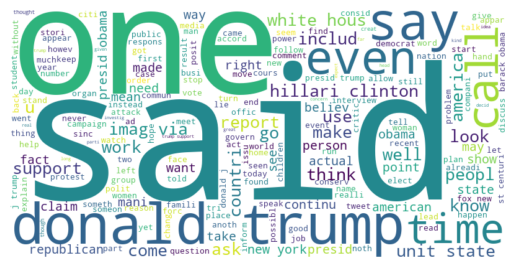

In [67]:
wc=WordCloud(height=400,width=800,background_color='white',stopwords=STOPWORDS).generate(fake_text)
plt.imshow(wc,interpolation='bilinear')
plt.axis('off')
plt.show()

In [68]:
fake_counter=Counter(fake_word)
print(f'Fake Word : {fake_counter.most_common(1000)}')

Fake Word : [('trump', 74145), ('said', 31014), ('presid', 27905), ('peopl', 26000), ('one', 23722), ('state', 23660), ('would', 23385), ('us', 21927), ('like', 21376), ('say', 20498), ('clinton', 18599), ('time', 18039), ('obama', 18020), ('donald', 17199), ('go', 16364), ('republican', 16033), ('american', 16013), ('also', 15221), ('year', 15166), ('get', 15009), ('make', 14881), ('report', 14464), ('even', 14310), ('new', 14107), ('news', 14096), ('imag', 13844), ('hillari', 13555), ('support', 13194), ('white', 13174), ('call', 12958), ('nation', 12863), ('right', 12641), ('know', 12336), ('use', 12166), ('want', 12092), ('democrat', 11683), ('elect', 11540), ('campaign', 11488), ('hous', 11474), ('via', 11271), ('media', 10964), ('countri', 10717), ('think', 10624), ('take', 10585), ('america', 10578), ('work', 10466), ('vote', 10426), ('show', 10352), ('polit', 10329), ('could', 10181), ('come', 10157), ('offic', 10110), ('first', 10006), ('mani', 9714), ('govern', 9393), ('back'

# WordCloud for True data

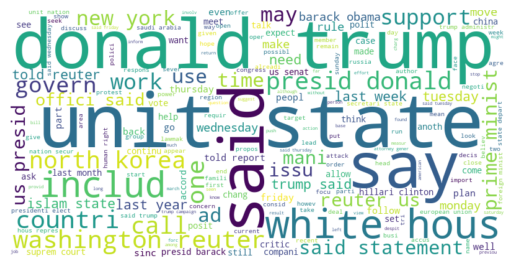

In [69]:
wc=WordCloud(height=400,width=800,background_color='white',stopwords=STOPWORDS).generate(true_text)
plt.imshow(wc,interpolation='bilinear')
plt.axis('off')
plt.show()

In [70]:
true_counter=Counter(true_word)
print(f'True Word : {true_counter.most_common(1000)}')

True Word : [('said', 98994), ('’', 70765), ('trump', 54359), ('“', 54139), ('”', 53860), ('us', 41132), ('state', 36616), ('would', 31511), ('reuter', 28390), ('presid', 28376), ('republican', 22113), ('govern', 20215), ('year', 19266), ('hous', 17526), ('new', 16781), ('unit', 16501), ('democrat', 16219), ('also', 15946), ('say', 15943), ('senat', 15706), ('elect', 15525), ('peopl', 15320), ('parti', 15005), ('offici', 14888), ('nation', 14330), ('told', 14233), ('countri', 14093), ('could', 13705), ('report', 13615), ('one', 13051), ('last', 12870), ('washington', 12426), ('support', 12188), ('includ', 12177), ('vote', 11937), ('campaign', 11919), ('two', 11615), ('call', 11597), ('secur', 11537), ('group', 11188), ('former', 10599), ('leader', 10516), ('week', 10492), ('court', 10458), ('donald', 10450), ('percent', 10006), ('north', 9832), ('plan', 9806), ('polit', 9688), ('minist', 9539), ('clinton', 9519), ('white', 9503), ('law', 9452), ('time', 9436), ('tax', 9322), ('obama', 

In [71]:
X=df['text']
y=df['Class']

In [72]:
print(y)

2915     1
39470    0
16174    1
18424    1
38691    0
        ..
11284    1
44732    0
38158    0
860      1
15795    1
Name: Class, Length: 44878, dtype: int64


In [73]:
print(X)

2915     moscow reuter russia unit state still discuss ...
39470    republican rep steve king base go behind presi...
16174    monrovia reuter liberia rule parti whose candi...
18424    washington reuter us senat stress trade busi i...
38691    bank powerhous european prime minist major arm...
                               ...                        
11284    abuja reuter unit state formal agre sell super...
44732    tune altern current radio network acr anoth li...
38158    main stream media choos ignor fact mani statem...
860      washington reuter republican tax plan unveil t...
15795    sydney reuter un high commission refuge said a...
Name: text, Length: 44878, dtype: object


In [74]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
X_train_vector=vectorizer.fit_transform(X_train)
X_test_vector=vectorizer.transform(X_test)

In [75]:
print(X_train_vector.shape,X_test_vector.shape,y_train.shape,y_test.shape)

(35902, 154444) (8976, 154444) (35902,) (8976,)


# Train Model

In [76]:
model.fit(X_train_vector,y_train)
y_pred=model.predict(X_test_vector)
print(f'Train Score :{model.score(X_train_vector,y_train)}')
print(f'Accuracy Score :{accuracy_score(y_test,y_pred)}')
print(f'Precision Score :{precision_score(y_test,y_pred)}')
print(f'Confusion Matrix :{confusion_matrix(y_test,y_pred)}')
print(f'Classification report :{classification_report(y_test,y_pred)}')

Train Score :0.9900562642749707
Accuracy Score :0.9856283422459893
Precision Score :0.9818983522859132
Confusion Matrix :[[4616   78]
 [  51 4231]]
Classification report :              precision    recall  f1-score   support

           0       0.99      0.98      0.99      4694
           1       0.98      0.99      0.98      4282

    accuracy                           0.99      8976
   macro avg       0.99      0.99      0.99      8976
weighted avg       0.99      0.99      0.99      8976



In [77]:
def prediction(text):
    text=clean_text(str(text))
    text_vector=vectorizer.transform([text])
    result=model.predict(text_vector)

    if result[0]==1:
        print("Real News")

    else:
        print("Fake News")

# Fake News

In [78]:
prediction(fake_testing_data['text'][23471])

Fake News


In [79]:
prediction(fake_testing_data['text'][23472])

Fake News


In [80]:
prediction("GENEVA - A shocking leaked document from the World Health Organization has confirmed what millions suspected.According to an insider who wishes to remain anonymous for safety, page 37 of the '2024 Internal Guidelines' clearly states that all COVID-19 vaccines were fitted with nano-tracking devices.The government is using 5G towers to activate these chips and monitor your every move. Share this with everyone before Facebook DELETES this post. They don't want you to know the truth!!! Mainstream media will never report this because they are PAID to hide it.Dr. Anthony Fauci was reportedly seen destroying evidence last Tuesday. Why else would billionaires buy underground bunkers? Wake up!!! Type AGREE if you will REFUSE the next booster.")

Fake News


# Real News

In [81]:
prediction(true_testing_data['text'][21409])

Real News


In [82]:
prediction(true_testing_data['text'][21412])

Real News


In [83]:
prediction("WASHINGTON/CAIRO, April 20 (Reuters) - Concerns grew on Monday that the ceasefire between the United States and Iran might not hold after the U.S. said it had seized an Iranian cargo ship that tried to run its blockade and Iran vowed to retaliate.")

Real News
